James Caldwell, UVA IRA, 6/8/26 <br>
A quick script for analyzing how class sizes changed from year to year at UVA.

In [ ]:
import pandas as pd
import numpy as np

data = pd.read_excel(r'')

In [18]:
data.head(25)

,Term Desc,Subject,Catalog Number,Class Title,Class Size Intervals,unique ID
0,2024 Fall,AAS,4501,Adv Res Sem in Hist & AAS,2-9,Adv Res Sem in Hist & AAS2024 Fall2-9
1,2025 Fall,AAS,4501,Adv Res Sem in Hist & AAS,2-9,Adv Res Sem in Hist & AAS2025 Fall2-9
2,2024 Fall,AAS,4570,Adv Research Sem in AAS,2-9,Adv Research Sem in AAS2024 Fall2-9
3,2025 Fall,AAS,4570,Adv Research Sem in AAS,10-19,Adv Research Sem in AAS2025 Fall10-19
4,2025 Fall,AAS,2210,African Literatures & Cultures,10-19,African Literatures & Cultures2025 Fall10-19
5,2024 Fall,AAS,1010,African-Amer & African Stds I,100+,African-Amer & African Stds I2024 Fall100+
6,2025 Fall,AAS,1010,African-Amer & African Stds I,100+,African-Amer & African Stds I2025 Fall100+
7,2025 Fall,AAS,2240,Africans in America,20-29,Africans in America2025 Fall20-29
8,2025 Fall,AAS,3770,Black Girlhood & the Media,20-29,Black Girlhood & the Media2025 Fall20-29
9,2025 Fall,AAS,4109,Civil Rights Movement & Media,-,Civil Rights Movement & Media2025 Fall-


In [17]:
data['unique ID'] = data['Class Title'] + data['Term Desc'] + data['Class Size Intervals']

In [4]:
data.sort_values(by=['Class Title', 'Class Size Intervals'], inplace=True,
                 ascending=False)

In [6]:
data.drop_duplicates(subset=['Class Title', 'Term Desc'], inplace=True)

In [9]:
print(data['Class Size Intervals'].value_counts())

10-19    1012
2-9       902
20-29     603
50-99     535
30-39     330
40-49     222
100+      199
-          66
Name: Class Size Intervals, dtype: int64



CLASS SIZE CHANGE SUMMARY
----------------------------------------
Total Classes: 1,440
Grew:          284 (19.7%)
Shrank:        249 (17.3%)
No Change:     907 (63.0%)

TRANSITION MATRIX
----------------------------------------
2025 Fall  -  2-9  10-19  20-29  30-39  40-49  50-99  100+
2024 Fall                                                 
-          5   12      0      0      0      0      0     0
2-9        4  226     72     10      2      1      0     1
10-19      1   60    218     50      5      1      0     0
20-29      0   12     53    117     34      2      3     1
30-39      0    3      7     38     55     19     17     2
40-49      0    0      1      4     15     41     35     1
50-99      0    0      1      5      7     23    173    16
100+       0    1      0      2      1      0     11    72

TOP 20 TRANSITIONS
----------------------------------------
2024 Fall 2025 Fall  Count
      2-9       2-9    226
    10-19     10-19    218
    50-99     50-99    173
    20-29  

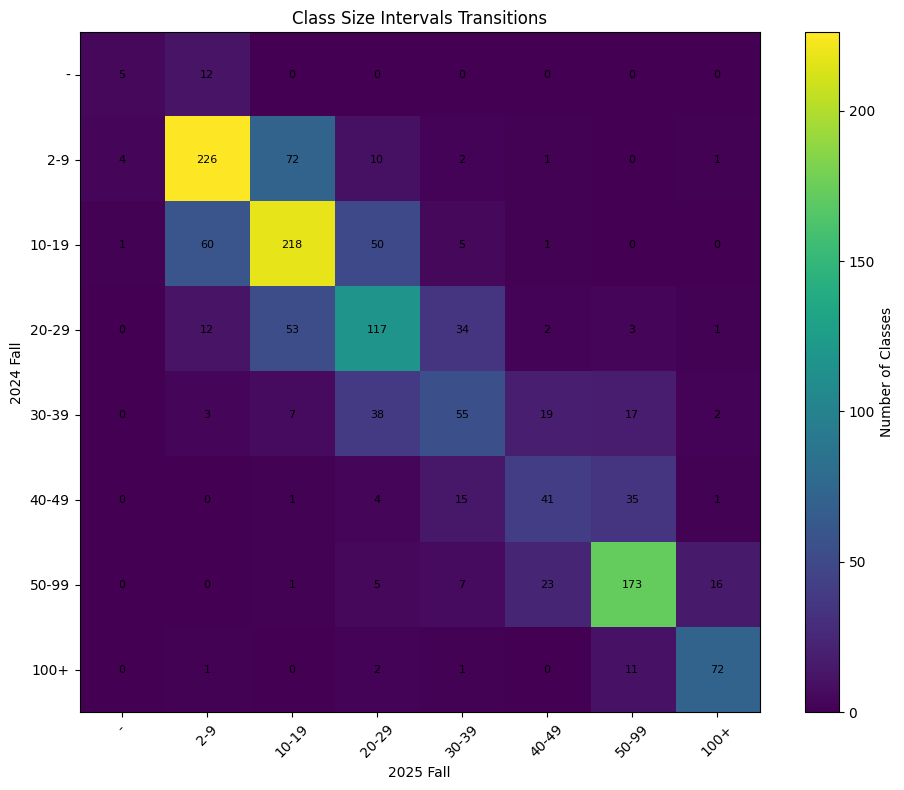


CHANGE IN NUMBER OF CLASSES BY SIZE INTERVAL
----------------------------------------
       2024 Fall  2025 Fall  Difference
-             17         10          -7
2-9          316        314          -2
10-19        335        352          17
20-29        222        226           4
30-39        141        119         -22
40-49         97         87         -10
50-99        225        239          14
100+          87         93           6


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Create one row per class with 2024 Fall and 2025 Fall side-by-side
# ------------------------------------------------------------------

wide = (
    data[['Term Desc', 'Class Title', 'Class Size Intervals']]
    .pivot(
        index='Class Title',
        columns='Term Desc',
        values='Class Size Intervals'
    )
    .reset_index()
)

# Remove classes that don't exist in both years
wide = wide.dropna(subset=['2024 Fall', '2025 Fall'])

# ------------------------------------------------------------------
# Define ordering of size intervals
# ------------------------------------------------------------------

order = {
    '-': 0,
    '2-9': 1,
    '10-19': 2,
    '20-29': 3,
    '30-39': 4,
    '40-49': 5,
    '50-99': 6,
    '100+': 7
}

wide['2024_rank'] = wide['2024 Fall'].map(order)
wide['2025_rank'] = wide['2025 Fall'].map(order)

wide['change'] = wide['2025_rank'] - wide['2024_rank']

# ------------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------------

total_classes = len(wide)
grew = (wide['change'] > 0).sum()
shrank = (wide['change'] < 0).sum()
same = (wide['change'] == 0).sum()

print("\nCLASS SIZE CHANGE SUMMARY")
print("-" * 40)
print(f"Total Classes: {total_classes:,}")
print(f"Grew:          {grew:,} ({grew/total_classes:.1%})")
print(f"Shrank:        {shrank:,} ({shrank/total_classes:.1%})")
print(f"No Change:     {same:,} ({same/total_classes:.1%})")

# ------------------------------------------------------------------
# Transition Matrix
# ------------------------------------------------------------------

interval_order = [
    '-',
    '2-9',
    '10-19',
    '20-29',
    '30-39',
    '40-49',
    '50-99',
    '100+'
]

transition = pd.crosstab(
    wide['2024 Fall'],
    wide['2025 Fall']
)

transition = transition.reindex(
    index=interval_order,
    columns=interval_order,
    fill_value=0
)

print("\nTRANSITION MATRIX")
print("-" * 40)
print(transition)

# ------------------------------------------------------------------
# Most common transitions
# ------------------------------------------------------------------

transitions_long = (
    wide.groupby(['2024 Fall', '2025 Fall'])
    .size()
    .reset_index(name='Count')
    .sort_values('Count', ascending=False)
)

print("\nTOP 20 TRANSITIONS")
print("-" * 40)
print(transitions_long.head(20).to_string(index=False))

# ------------------------------------------------------------------
# Specific examples requested
# ------------------------------------------------------------------

print("\nEXAMPLE TRANSITIONS")
print("-" * 40)

examples = [
    ('50-99', '100+'),
    ('100+', '50-99'),
    ('20-29', '50-99'),
    ('10-19', '20-29')
]

for old, new in examples:
    count = transition.loc[old, new]
    print(f"{old:>5} -> {new:<5}: {count}")

# ------------------------------------------------------------------
# Largest increases
# ------------------------------------------------------------------

print("\nTOP 20 LARGEST INCREASES")
print("-" * 40)

largest_gains = (
    wide[wide['change'] > 0]
    .sort_values('change', ascending=False)
    [['Class Title', '2024 Fall', '2025 Fall', 'change']]
)

print(largest_gains.head(20).to_string(index=False))

# ------------------------------------------------------------------
# Largest decreases
# ------------------------------------------------------------------

print("\nTOP 20 LARGEST DECREASES")
print("-" * 40)

largest_losses = (
    wide[wide['change'] < 0]
    .sort_values('change')
    [['Class Title', '2024 Fall', '2025 Fall', 'change']]
)

print(largest_losses.head(20).to_string(index=False))

# ------------------------------------------------------------------
# Heatmap Visualization
# ------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(transition.values)

ax.set_xticks(range(len(transition.columns)))
ax.set_yticks(range(len(transition.index)))

ax.set_xticklabels(transition.columns, rotation=45)
ax.set_yticklabels(transition.index)

ax.set_xlabel("2025 Fall")
ax.set_ylabel("2024 Fall")
ax.set_title("Class Size Intervals Transitions")

# Annotate counts
for i in range(len(transition.index)):
    for j in range(len(transition.columns)):
        value = transition.iloc[i, j]
        ax.text(
            j,
            i,
            str(value),
            ha='center',
            va='center',
            fontsize=8
        )

plt.colorbar(im, label="Number of Classes")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Net movement by interval
# ------------------------------------------------------------------

fall2024_counts = (
    wide['2024 Fall']
    .value_counts()
    .reindex(interval_order, fill_value=0)
)

fall2025_counts = (
    wide['2025 Fall']
    .value_counts()
    .reindex(interval_order, fill_value=0)
)

comparison = pd.DataFrame({
    '2024 Fall': fall2024_counts,
    '2025 Fall': fall2025_counts
})

comparison['Difference'] = (
    comparison['2025 Fall']
    - comparison['2024 Fall']
)

print("\nCHANGE IN NUMBER OF CLASSES BY SIZE INTERVAL")
print("-" * 40)
print(comparison)